In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')

In [3]:
df.sample()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1873,18,Male,Australia,High School,Facebook,Networking,4.4,157,3.6,2.5,6.5,High,6.5


In [4]:
df.duplicated().sum()

np.int64(2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Density'>

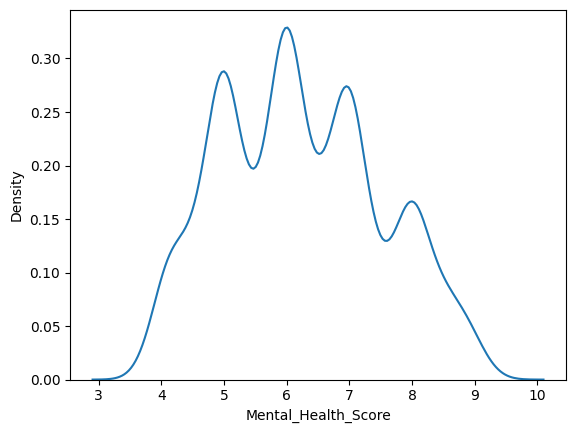

In [7]:
sns.kdeplot(df['Mental_Health_Score'])

<Axes: >

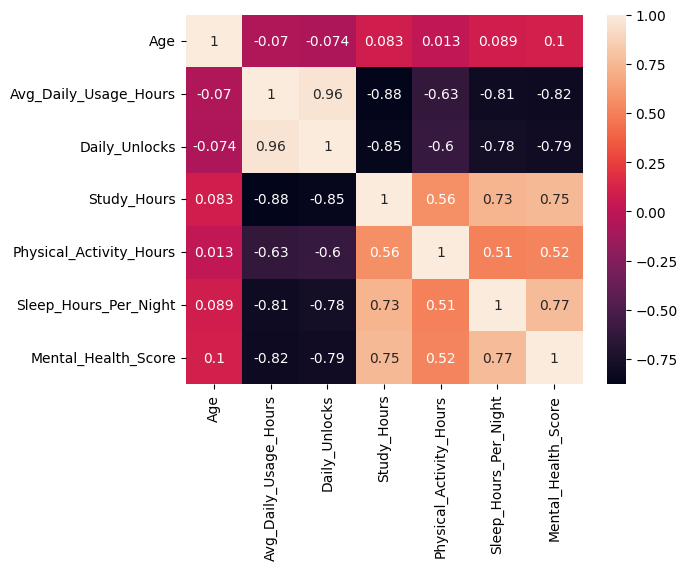

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

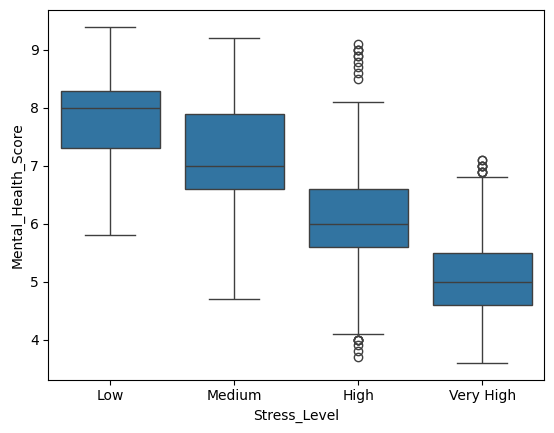

In [9]:
df['Stress_Level'].unique()
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(data=df,x='Stress_Level',y='Mental_Health_Score',order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

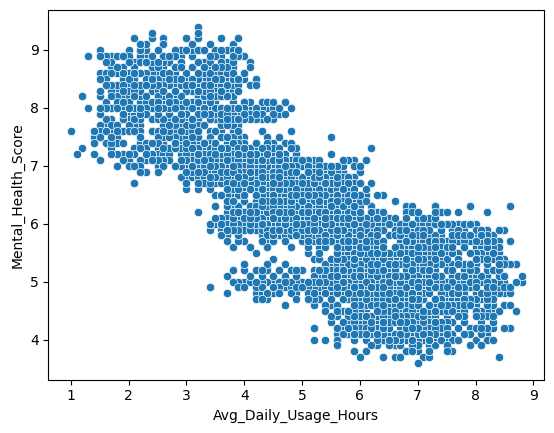

In [10]:
sns.scatterplot(data=df,x='Avg_Daily_Usage_Hours',y='Mental_Health_Score')

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

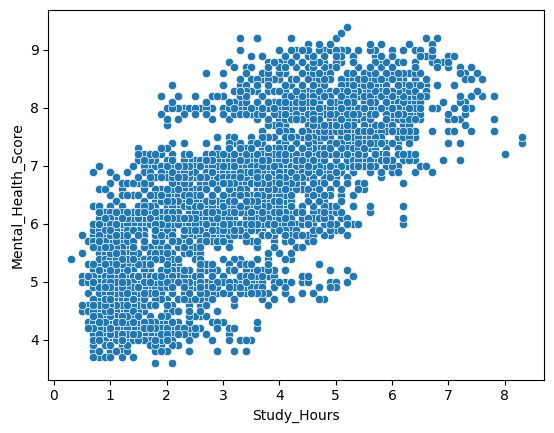

In [11]:
sns.scatterplot(data=df,x='Study_Hours',y='Mental_Health_Score')

<Axes: xlabel='count', ylabel='Most_Used_Platform'>

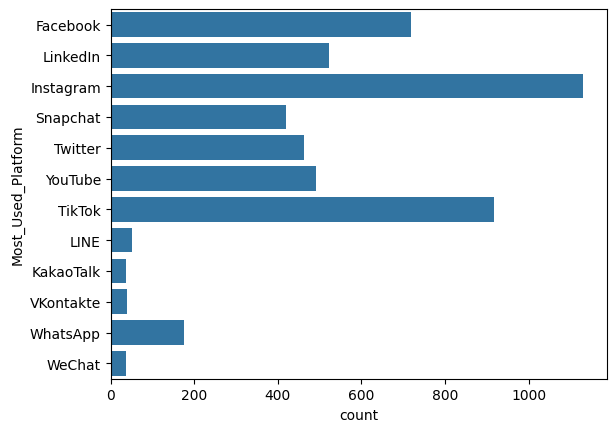

In [12]:
sns.countplot(df['Most_Used_Platform'])

In [13]:
num_features = df.select_dtypes(include='number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [16]:
numeric_cols = df.select_dtypes(include='number')
numeric_cols.skew()
# 0 - centralized/bell-shaped curve
# positive - right skewed
# negative - left skewed

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [17]:
top_countries = df['Country'].value_counts().head(10).index.tolist()
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

df['Group_Country'] = df['Country'].apply(group_countries)

In [20]:
numeric_cols.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [21]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Group_Country'],
      dtype='object')

In [22]:
skew_cols = ['Study_Hours']
numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_cols = ['Stress_Level']
nominal_cols = ['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Group_Country']

feature_cols = skew_cols + numeric_cols + ordinal_cols + nominal_cols
X = df[feature_cols]
y = df['Mental_Health_Score']

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder

# Skew Pipeline
skew_pipeline = Pipeline(steps=[
    ('transform',FunctionTransformer(func=np.log1p)),
    ('scale',StandardScaler())
])

# Numeric Pipeline
numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

# Ordinal Encoding pipeline
ordinal_pipeline = Pipeline(steps=[
    ('ordinal_encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

# One Hot Encoding pipeline
nominal_pipeline = Pipeline(steps=[
    ('ohe_encode',OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('skew',skew_pipeline,skew_cols),
    ('numeric',numeric_pipeline,numeric_cols),
    ('ordinal',ordinal_pipeline,ordinal_cols),
    ('nominal',nominal_pipeline,nominal_cols)
])

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Linear Regression - Baseline Model

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [29]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])
lr_pipeline.fit(X_train,y_train)
y_pred = lr_pipeline.predict(X_test)
y_pred_train = lr_pipeline.predict(X_train)
print(f"Training Accuracy : {r2_score(y_train,y_pred_train)}")
print(f"Testing Accuracy : {r2_score(y_test,y_pred)}")
print(f"MAE : {mean_absolute_error(y_test,y_pred)}")

Training Accuracy : 0.7255672449830839
Testing Accuracy : 0.742812906901333
MAE : 0.5338894857575271


Random Forest Regression

In [30]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor())
])
rf_pipeline.fit(X_train,y_train)
y_pred = rf_pipeline.predict(X_test)
y_pred_train = rf_pipeline.predict(X_train)
print(f"Training Accuracy : {r2_score(y_train,y_pred_train)}")
print(f"Testing Accuracy : {r2_score(y_test,y_pred)}")
print(f"MAE : {mean_absolute_error(y_test,y_pred)}")

Training Accuracy : 0.9828504496159765
Testing Accuracy : 0.8878998510644582
MAE : 0.3296619166666668


Random Forest Regression - Hyperparameter Tuning

In [32]:
from sklearn.model_selection import RandomizedSearchCV

In [39]:
param_grid = {
    'model__n_estimators' : [50,100,200],
    'model__criterion' : ['squared_error','poisson'],
    'model__max_depth' : [2,5,10,100],
    'model__min_samples_split' : [2,5,10,50],
    'model__min_samples_leaf' : [1,2,5,10]
}

clf = RandomizedSearchCV(rf_pipeline,param_grid,n_iter=10,cv=5,scoring='r2',n_jobs=-1)
search = clf.fit(X_train,y_train)

In [40]:
search.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_depth': 10,
 'model__criterion': 'poisson'}

In [42]:
best_rf_pipeline = search.best_estimator_
y_pred = best_rf_pipeline.predict(X_test)
print(f"Testing Accuracy : {r2_score(y_test,y_pred)}")
print(f"MAE : {mean_absolute_error(y_test,y_pred)}")

Testing Accuracy : 0.8477754659350194
MAE : 0.40021144812533566


In [44]:
import joblib
joblib.dump(rf_pipeline,'model_mental_health.pkl')

['model_mental_health.pkl']